# EXPERIMENT NO: 7
## Clustering using K-Means and Gaussian Mixture Models (GMM)


---
## SCENARIO 1 — CLUSTERING USING K-MEANS
**Dataset:** Mall Customer Segmentation Dataset (Kaggle)  
**Link:** https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

In [1]:
# Task 1: Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Task 2: Load the dataset
# Download from Kaggle and place Mall_Customers.csv in the working directory
df = pd.read_csv('..\DATASET\Mall_Customers.csv') #""W:\kct\ML\7810\files\EX-7\DATASET""
print("Shape:", df.shape)
print(df.head())

Shape: (200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [3]:
# Task 3: Data Preprocessing
print("Missing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)
print("\nBasic statistics:\n", df.describe())

Missing values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Data types:
 CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Basic statistics:
        CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.00

In [4]:
# Task 4: Select relevant features
features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].values

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features selected and scaled.")
print("Scaled data sample:\n", X_scaled[:5])

Features selected and scaled.
Scaled data sample:
 [[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


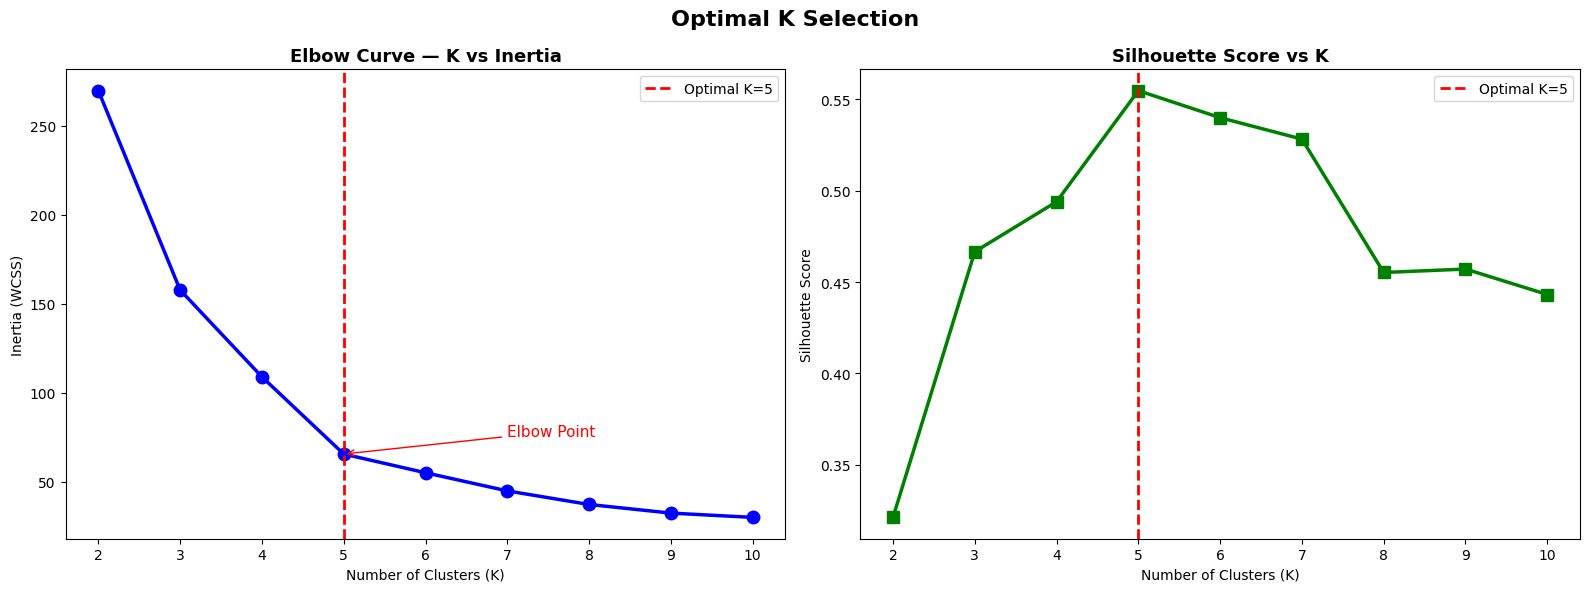


📌 Best Silhouette Score: 0.5547 at K=5


In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Range of K
K_range = range(2, 11)   # silhouette requires at least 2 clusters

inertia_values = []
silhouette_values = []

# Compute both inertia and silhouette
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, labels))

# ─── Plot Elbow Curve + Silhouette Scores ───
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Optimal K Selection', fontsize=16, fontweight='bold')

# Elbow Curve
axes[0].plot(list(K_range), inertia_values, 'bo-', linewidth=2.5, markersize=9)
axes[0].axvline(x=5, color='red', linestyle='--', linewidth=2, label='Optimal K=5')
axes[0].set_title('Elbow Curve — K vs Inertia', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].legend()
axes[0].set_xticks(list(K_range))

# Annotate elbow point (adjust index carefully!)
axes[0].annotate('Elbow Point', xy=(5, inertia_values[5-2]),
                 xytext=(7, inertia_values[5-2] + 10),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=11, color='red')

# Silhouette Score
axes[1].plot(list(K_range), silhouette_values, 'gs-', linewidth=2.5, markersize=9)
axes[1].axvline(x=5, color='red', linestyle='--', linewidth=2, label='Optimal K=5')
axes[1].set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.savefig('elbow_silhouette_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Best silhouette score
best_k = list(K_range)[silhouette_values.index(max(silhouette_values))]
print(f"\n📌 Best Silhouette Score: {max(silhouette_values):.4f} at K={best_k}")

In [6]:
# Task 6 & 7: Apply K-Means clustering with optimal K=5
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Assign cluster labels
df['KMeans_Cluster'] = kmeans.labels_
print("Cluster distribution:")
print(df['KMeans_Cluster'].value_counts())

Cluster distribution:
KMeans_Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


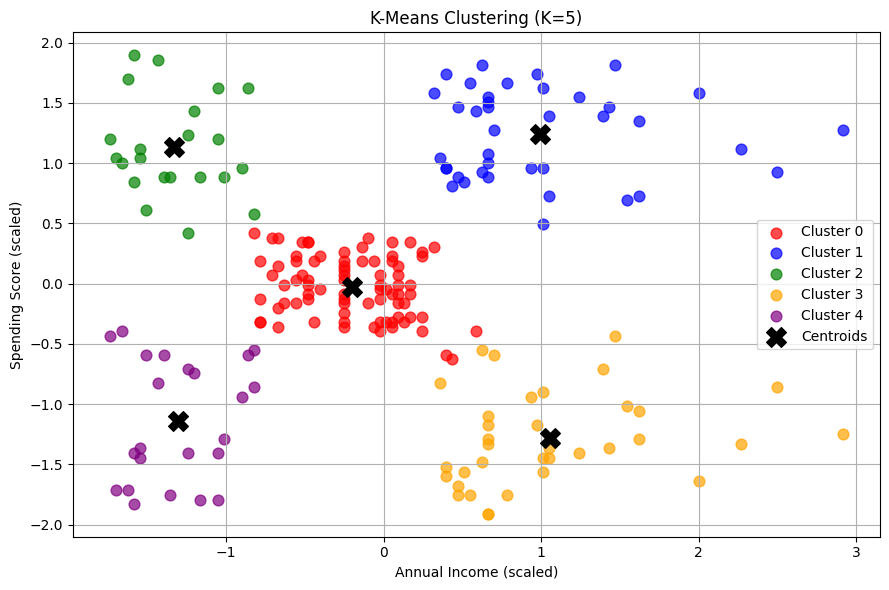

In [7]:
# Task 8: Visualize clusters
colors = ['red', 'blue', 'green', 'orange', 'purple']
plt.figure(figsize=(9, 6))

for cluster_id in range(optimal_k):
    cluster_points = X_scaled[df['KMeans_Cluster'] == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                color=colors[cluster_id], label=f'Cluster {cluster_id}', s=60, alpha=0.7)

# Plot centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],
            color='black', marker='X', s=200, label='Centroids', zorder=5)

plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.title(f'K-Means Clustering (K={optimal_k})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
# Task 9: Evaluation Metrics
inertia = kmeans.inertia_
sil_score = silhouette_score(X_scaled, kmeans.labels_)

print(f"Inertia (WCSS): {inertia:.4f}")
print(f"Silhouette Score: {sil_score:.4f}")

# Interpret cluster characteristics
print("\nCluster Characteristics (original scale):")
cluster_summary = df.groupby('KMeans_Cluster')[features].mean()
print(cluster_summary)

Inertia (WCSS): 65.5684
Silhouette Score: 0.5547

Cluster Characteristics (original scale):
                Annual Income (k$)  Spending Score (1-100)
KMeans_Cluster                                            
0                        55.296296               49.518519
1                        86.538462               82.128205
2                        25.727273               79.363636
3                        88.200000               17.114286
4                        26.304348               20.913043


---
## SCENARIO 2 — CLUSTERING USING GMM
**Dataset:** Same Mall Customer Dataset

In [9]:
from sklearn.mixture import GaussianMixture
import matplotlib.patches as mpatches

# Task 3 & 4: Apply GMM with chosen number of components
n_components = 5
gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
gmm.fit(X_scaled)

print(f"GMM fitted with {n_components} components.")
print(f"Converged: {gmm.converged_}")

GMM fitted with 5 components.
Converged: True


In [10]:
# Task 6 & 7: Predict cluster probabilities and assign labels
probs = gmm.predict_proba(X_scaled)
df['GMM_Cluster'] = gmm.predict(X_scaled)

print("GMM Cluster distribution:")
print(df['GMM_Cluster'].value_counts())

print("\nSample cluster probabilities (first 5 rows):")
prob_df = pd.DataFrame(probs, columns=[f'P(Cluster {i})' for i in range(n_components)])
print(prob_df.head())

GMM Cluster distribution:
GMM_Cluster
0    84
1    39
3    33
4    23
2    21
Name: count, dtype: int64

Sample cluster probabilities (first 5 rows):
   P(Cluster 0)  P(Cluster 1)  P(Cluster 2)  P(Cluster 3)  P(Cluster 4)
0  1.576897e-05  1.880092e-08  9.520312e-04  5.200131e-08      0.999032
1  1.627762e-05  1.895968e-04  9.997902e-01  4.210134e-23      0.000004
2  2.213394e-19  9.526157e-19  1.225495e-12  1.862233e-04      0.999814
3  1.054448e-04  1.800877e-04  9.996937e-01  3.793901e-21      0.000021
4  6.473014e-05  3.842732e-08  1.556695e-03  4.757227e-08      0.998378


In [11]:
# GMM Evaluation Metrics
log_likelihood = gmm.score(X_scaled) * len(X_scaled)
aic = gmm.aic(X_scaled)
bic = gmm.bic(X_scaled)
gmm_sil = silhouette_score(X_scaled, df['GMM_Cluster'])

print(f"Log-Likelihood : {log_likelihood:.4f}")
print(f"AIC            : {aic:.4f}")
print(f"BIC            : {bic:.4f}")
print(f"Silhouette Score: {gmm_sil:.4f}")

Log-Likelihood : -452.5005
AIC            : 963.0010
BIC            : 1058.6523
Silhouette Score: 0.5537


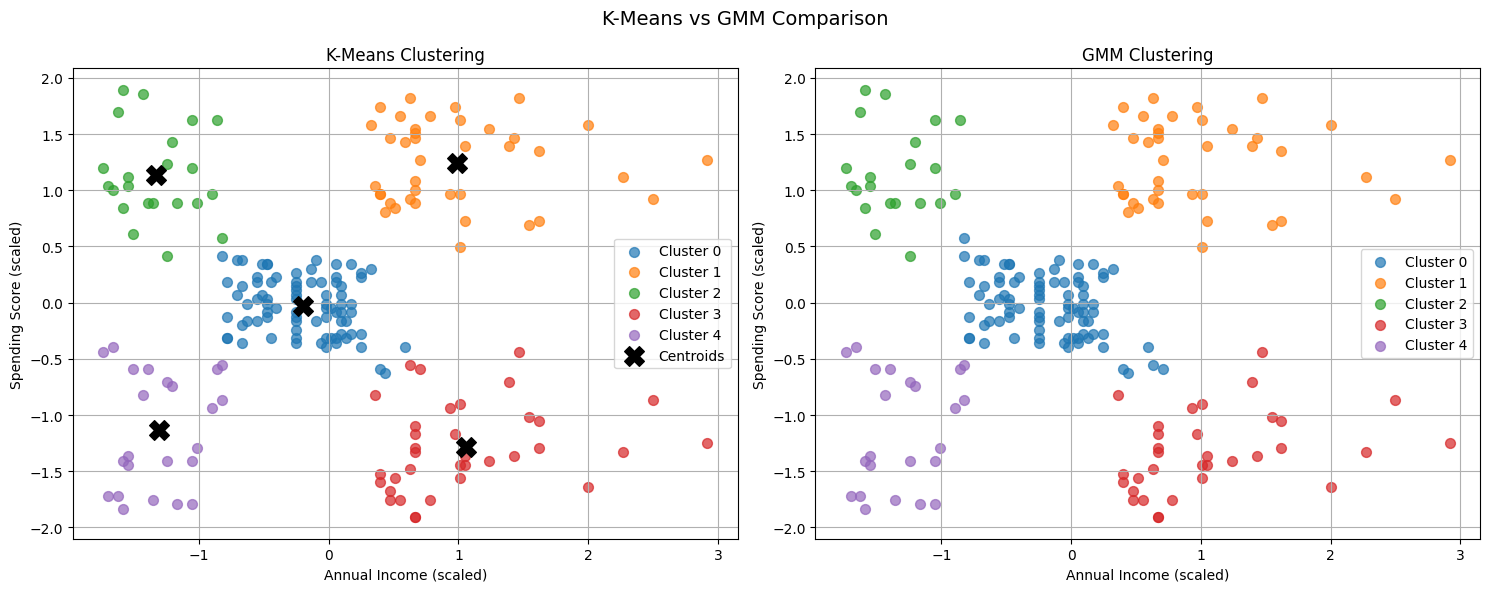

In [12]:
# Task 8: Compare K-Means vs GMM — Side-by-side scatter plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# K-Means
for cluster_id in range(optimal_k):
    pts = X_scaled[df['KMeans_Cluster'] == cluster_id]
    axes[0].scatter(pts[:, 0], pts[:, 1], label=f'Cluster {cluster_id}', s=50, alpha=0.7)
axes[0].scatter(centroids[:, 0], centroids[:, 1], color='black', marker='X', s=200, label='Centroids', zorder=5)
axes[0].set_title('K-Means Clustering')
axes[0].set_xlabel('Annual Income (scaled)')
axes[0].set_ylabel('Spending Score (scaled)')
axes[0].legend()
axes[0].grid(True)

# GMM
for cluster_id in range(n_components):
    pts = X_scaled[df['GMM_Cluster'] == cluster_id]
    axes[1].scatter(pts[:, 0], pts[:, 1], label=f'Cluster {cluster_id}', s=50, alpha=0.7)
axes[1].set_title('GMM Clustering')
axes[1].set_xlabel('Annual Income (scaled)')
axes[1].set_ylabel('Spending Score (scaled)')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('K-Means vs GMM Comparison', fontsize=14)
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

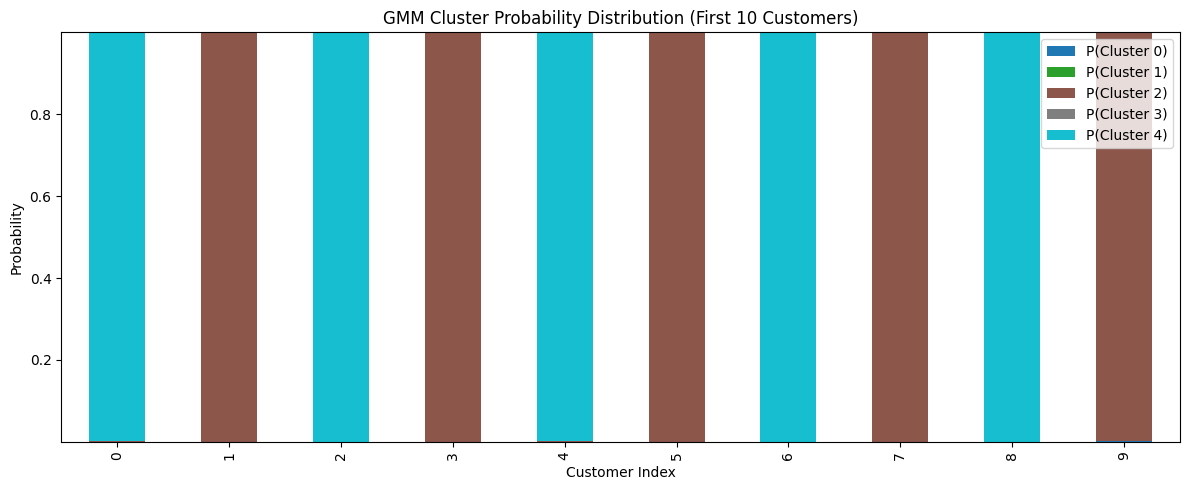

In [13]:
# Cluster probability distribution for first 10 customers
plt.figure(figsize=(12, 5))
prob_df.iloc[:10].plot(kind='bar', stacked=True, colormap='tab10', figsize=(12, 5))
plt.title('GMM Cluster Probability Distribution (First 10 Customers)')
plt.xlabel('Customer Index')
plt.ylabel('Probability')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [14]:
# Final Comparison Summary
print("=" * 50)
print("       COMPARISON: K-Means vs GMM")
print("=" * 50)
print(f"K-Means Silhouette Score : {sil_score:.4f}")
print(f"GMM     Silhouette Score : {gmm_sil:.4f}")
print(f"GMM AIC                  : {aic:.4f}")
print(f"GMM BIC                  : {bic:.4f}")
print("=" * 50)

       COMPARISON: K-Means vs GMM
K-Means Silhouette Score : 0.5547
GMM     Silhouette Score : 0.5537
GMM AIC                  : 963.0010
GMM BIC                  : 1058.6523
